# Decision Tree and Random Forest Tasks

#### The dataset belongs to a financial institution, and our goal is to predict whether a customer will repay the loan if it is granted.

## 1. Data Gathering

1.1 - Import Libraries

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, classification_report, accuracy_score

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score

1.2 - Read the data

* **credit.policy**: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
* **purpose**: The purpose of the loan (takes values `credit_card`, `debt_consolidation`, `educational`, `major_purchase`, `small_business`, and `all_other`).
* **int.rate**: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
* **installment**: The monthly installments owed by the borrower if the loan is funded.
* **log.annual.inc**: The natural log of the self-reported annual income of the borrower.
* **dti**: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
* **fico**: The FICO credit score of the borrower.
* **days.with.cr.line**: The number of days the borrower has had a credit line.
* **revol.bal**: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* **revol.util**: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
* **inq.last.6mths**: The borrower's number of inquiries by creditors in the last 6 months.
* **delinq.2yrs**: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
* **pub.rec**: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

In [113]:
df_train = pd.read_csv('train.csv')
print("Train head!")
display(df_train.head())

df_validation = pd.read_csv('validation.csv')
print("Validation head!")
display(df_validation.head())

Train head!


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


Validation head!


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,0,0.0800,125.35,10.308953,12.20,752,539.958333,70,2.9,0,0,0,0,0,0,0,0,1,0
1,0,0.1450,68.85,11.127263,24.16,662,5370.000000,10498,100.0,1,0,0,1,0,0,0,0,0,0
2,0,0.1134,210.56,10.645425,5.60,682,1199.958333,4713,61.2,6,0,0,1,0,0,0,0,0,0
3,0,0.1513,260.47,10.985361,17.59,647,3480.000000,8135,79.0,3,0,0,1,0,1,0,0,0,0
4,0,0.1482,138.31,10.126471,3.55,642,509.958333,2387,88.4,3,0,0,0,0,0,0,0,0,0


1.3 - Load the dataset and take a quick look at it, displaying general and statistical information as well.

In [114]:
display(df_train.describe())
display(df_train.info())

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
count,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000,8620.000000
mean,0.894432,0.120469,320.099195,10.925091,12.476188,712.756961,4568.668276,14515.896984,46.334517,1.295012,0.160673,0.060673,0.151508,0.132599,0.419142,0.034455,0.064153,0.045940,0.063921
std,0.307302,0.026059,205.311639,0.606275,6.850396,38.408086,2472.215150,21422.636765,29.094675,1.970745,0.543338,0.260139,0.358564,0.339160,0.493447,0.182405,0.245040,0.209366,0.244627
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.100800,164.227500,10.555813,7.120000,682.000000,2849.958333,3182.000000,21.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.121800,273.010000,10.915234,12.530000,707.000000,4139.958333,8489.500000,45.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.137900,435.550000,11.289782,17.800000,742.000000,5729.958333,17582.750000,70.500000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.212100,918.020000,14.528354,29.960000,827.000000,17639.958330,407794.000000,119.000000,33.000000,13.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8620 entries, 0 to 8619
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               8620 non-null   int64  
 1   int.rate                    8620 non-null   float64
 2   installment                 8620 non-null   float64
 3   log.annual.inc              8620 non-null   float64
 4   dti                         8620 non-null   float64
 5   fico                        8620 non-null   int64  
 6   days.with.cr.line           8620 non-null   float64
 7   revol.bal                   8620 non-null   int64  
 8   revol.util                  8620 non-null   float64
 9   inq.last.6mths              8620 non-null   int64  
 10  delinq.2yrs                 8620 non-null   int64  
 11  pub.rec                     8620 non-null   int64  
 12  not.fully.paid              8620 non-null   int64  
 13  purpose_credit_card         8620 

None

In [115]:
display(df_validation.describe())
display(df_validation.info())

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
count,958.0,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,9.580000e+02,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000,958.000000
mean,0.0,0.142179,310.003486,10.995338,13.780825,693.654489,4489.673974,3.849156e+04,50.980731,4.118998,0.191023,0.075157,0.236952,0.124217,0.359081,0.048017,0.079332,0.042797,0.070981
std,0.0,0.025931,222.186740,0.683990,7.075166,28.522528,2709.547253,8.217067e+04,27.951117,2.506509,0.571020,0.279178,0.425435,0.330001,0.479982,0.213913,0.270397,0.202506,0.256928
min,0.0,0.060000,31.200000,8.673000,0.000000,642.000000,390.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.127225,149.072500,10.595859,8.345000,672.000000,2520.000000,3.323750e+03,28.200000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.141100,246.600000,10.982318,14.090000,692.000000,4079.958333,9.681000e+03,51.200000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.156800,411.440000,11.407565,19.395000,712.000000,5904.750000,3.104500e+04,74.650000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,0.216400,940.140000,13.304685,29.900000,807.000000,15271.000000,1.207359e+06,106.400000,15.000000,5.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               958 non-null    int64  
 1   int.rate                    958 non-null    float64
 2   installment                 958 non-null    float64
 3   log.annual.inc              958 non-null    float64
 4   dti                         958 non-null    float64
 5   fico                        958 non-null    int64  
 6   days.with.cr.line           958 non-null    float64
 7   revol.bal                   958 non-null    int64  
 8   revol.util                  958 non-null    float64
 9   inq.last.6mths              958 non-null    int64  
 10  delinq.2yrs                 958 non-null    int64  
 11  pub.rec                     958 non-null    int64  
 12  not.fully.paid              958 non-null    int64  
 13  purpose_credit_card         958 non

None

## 2. Exploratory Data Analysis(EDA)

2.1 - Plot a histogram of the `fico` feature, separated by `credit.policy`, with the two distributions overlaid on the same chart.

fico_1_train:  7710
fico_0_train:  910
fico_1_validation:  0
fico_0_validation:  958


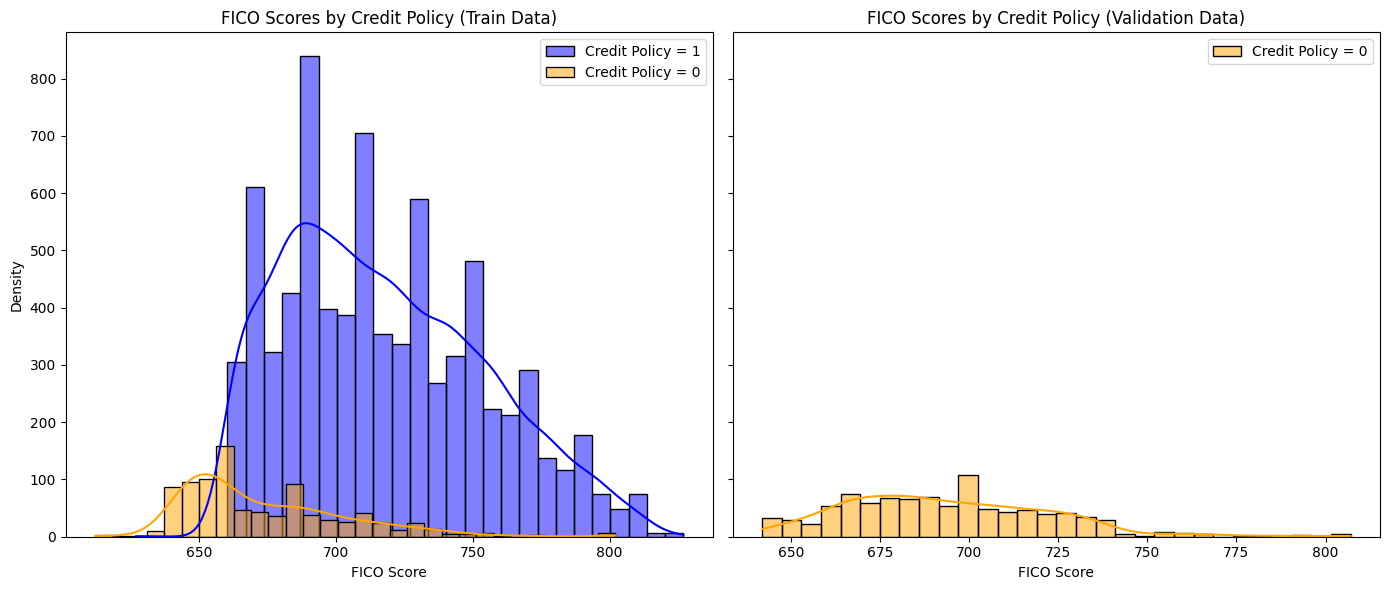

In [116]:
# Splitting the data based on credit.policy
fico_1_train = df_train[df_train['credit.policy'] == 1]['fico']
fico_0_train = df_train[df_train['credit.policy'] == 0]['fico']
print("fico_1_train: ", len(fico_1_train))
print("fico_0_train: ", len(fico_0_train))

fico_1_validation = df_validation[df_validation['credit.policy'] == 1]['fico']
fico_0_validation = df_validation[df_validation['credit.policy'] == 0]['fico']
print("fico_1_validation: ", len(fico_1_validation))
print("fico_0_validation: ", len(fico_0_validation))

# Plotting settings for two side-by-side plots with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Histogram and density for train data
sns.histplot(fico_1_train, bins=30, kde=True, color='blue', alpha=0.5, label='Credit Policy = 1', ax=axes[0])
sns.histplot(fico_0_train, bins=30, kde=True, color='orange', alpha=0.5, label='Credit Policy = 0', ax=axes[0])
axes[0].set_title('FICO Scores by Credit Policy (Train Data)')
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Histogram and density for validation data
sns.histplot(fico_1_validation, bins=30, kde=True, color='blue', alpha=0.5, label='Credit Policy = 1', ax=axes[1])
sns.histplot(fico_0_validation, bins=30, kde=True, color='orange', alpha=0.5, label='Credit Policy = 0', ax=axes[1])
axes[1].set_title('FICO Scores by Credit Policy (Validation Data)')
axes[1].set_xlabel('FICO Score')
axes[1].set_ylabel('Density')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()


2.2 - Plot the same histogram as above, but this time separated by the label `not.fully.paid`.

fico_1_train:  1306
fico_0_train:  7314
fico_1_validation:  227
fico_0_validation:  731


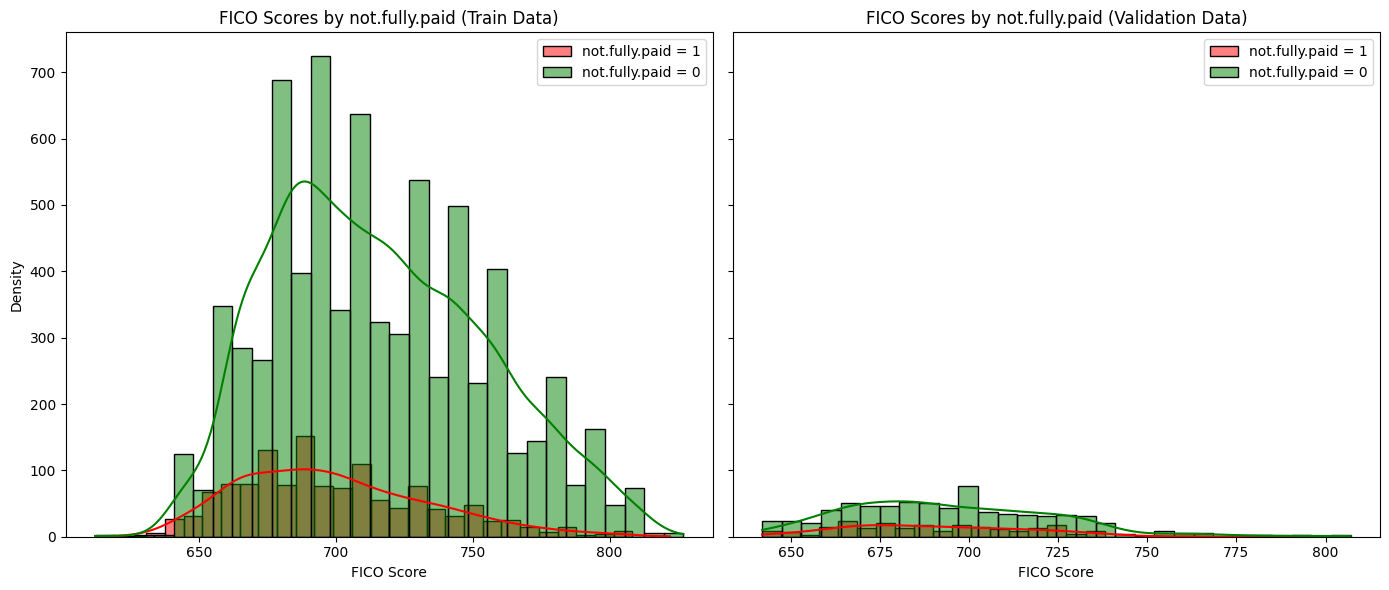

In [117]:
# Splitting the data based on credit.policy
fico_1_train = df_train[df_train['not.fully.paid'] == 1]['fico']
fico_0_train = df_train[df_train['not.fully.paid'] == 0]['fico']
print("fico_1_train: ", len(fico_1_train))
print("fico_0_train: ", len(fico_0_train))

fico_1_validation = df_validation[df_validation['not.fully.paid'] == 1]['fico']
fico_0_validation = df_validation[df_validation['not.fully.paid'] == 0]['fico']
print("fico_1_validation: ", len(fico_1_validation))
print("fico_0_validation: ", len(fico_0_validation))

# Plotting settings for two side-by-side plots with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Histogram and density for train data
sns.histplot(fico_1_train, bins=30, kde=True, color='red', alpha=0.5, label='not.fully.paid = 1', ax=axes[0])
sns.histplot(fico_0_train, bins=30, kde=True, color='green', alpha=0.5, label='not.fully.paid = 0', ax=axes[0])
axes[0].set_title('FICO Scores by not.fully.paid (Train Data)')
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Histogram and density for validation data
sns.histplot(fico_1_validation, bins=30, kde=True, color='red', alpha=0.5, label='not.fully.paid = 1', ax=axes[1])
sns.histplot(fico_0_validation, bins=30, kde=True, color='green', alpha=0.5, label='not.fully.paid = 0', ax=axes[1])
axes[1].set_title('FICO Scores by not.fully.paid (Validation Data)')
axes[1].set_xlabel('FICO Score')
axes[1].set_ylabel('Density')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()


2.3 - Plot a jointplot for the features `fico` and `int.rate`.

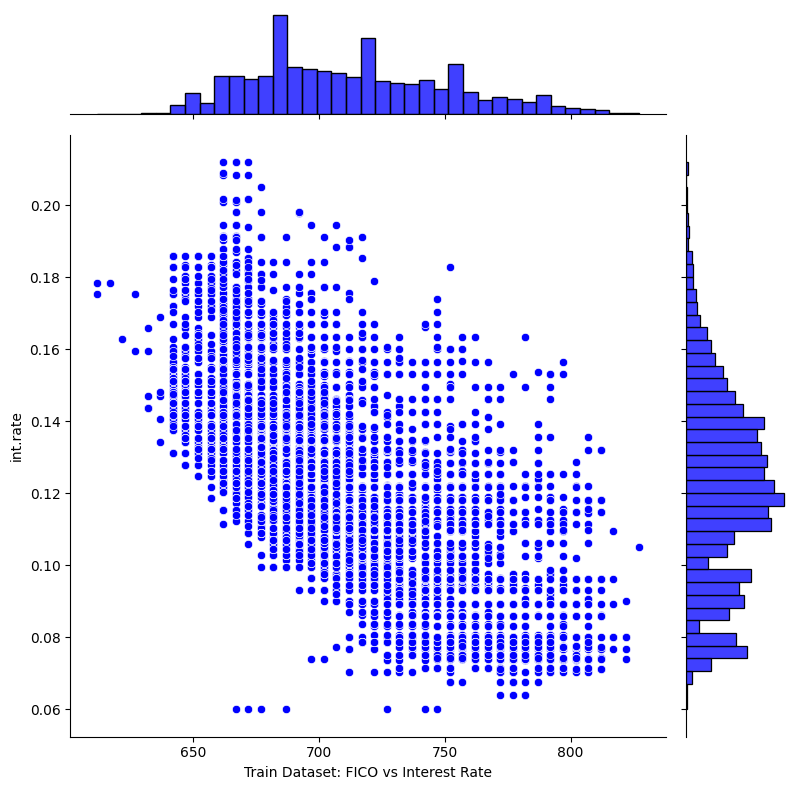

In [118]:
# Creating the jointplot
# sns.jointplot(data=df_train, x='fico', y='int.rate', kind='scatter', color='blue')
sns.jointplot(data=df_train, x='fico', y='int.rate', kind='scatter', color='blue', height=8)


# Display the plot
plt.xlabel('Train Dataset: FICO vs Interest Rate')
plt.show()


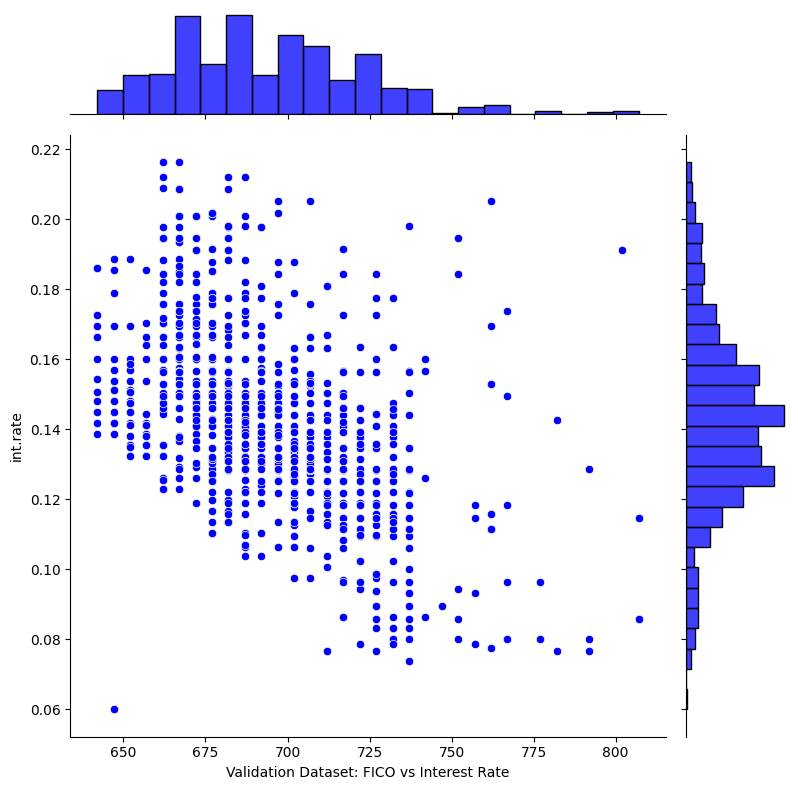

In [119]:
# Creating the jointplot
# sns.jointplot(data=df_validation, x='fico', y='int.rate', kind='scatter', color='blue')
sns.jointplot(data=df_validation, x='fico', y='int.rate', kind='scatter', color='blue', height=8)

# Display the plot
plt.xlabel('Validation Dataset: FICO vs Interest Rate')
plt.show()

2.5 It seems that we have discovered a correlation. To examine these correlations more precisely, plot an `lmplot` based on `fico`, with two separate columns indicating whether the loan was repaid or not, and distinguish by `credit.policy`.

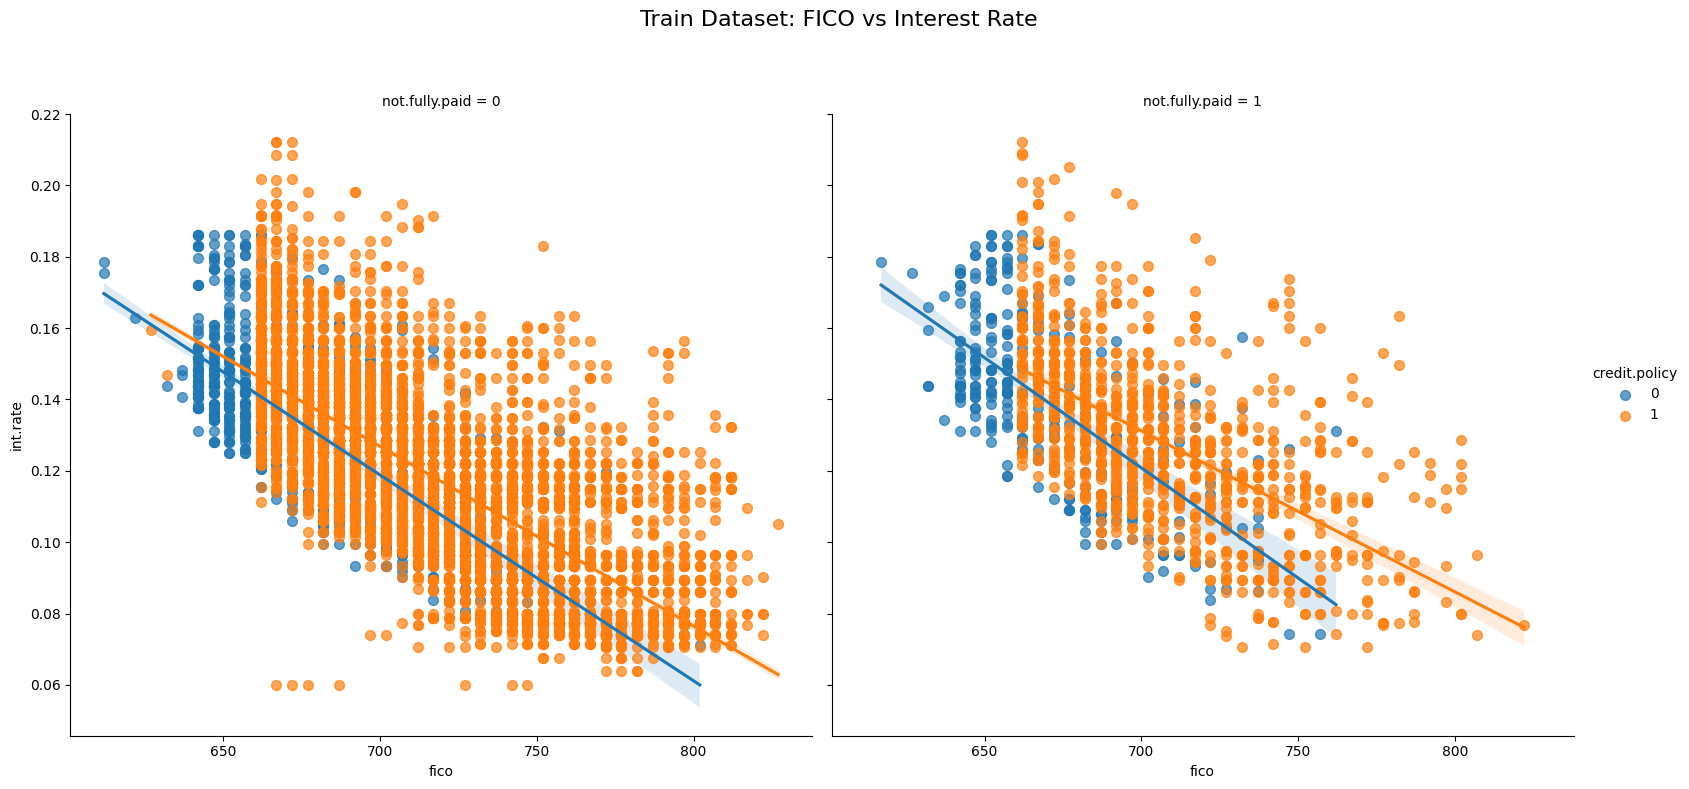

In [120]:
g = sns.lmplot(data=df_train, x='fico', y='int.rate', hue='credit.policy', col='not.fully.paid', 
               logistic=False, aspect=1, height=8, scatter_kws={'s': 50, 'alpha': 0.7})

# Add title to the plot
g.fig.suptitle('Train Dataset: FICO vs Interest Rate', fontsize=16)

# Adjust the layout to prevent title overlap
g.fig.subplots_adjust(top=0.85)

# Display the plot
plt.show()

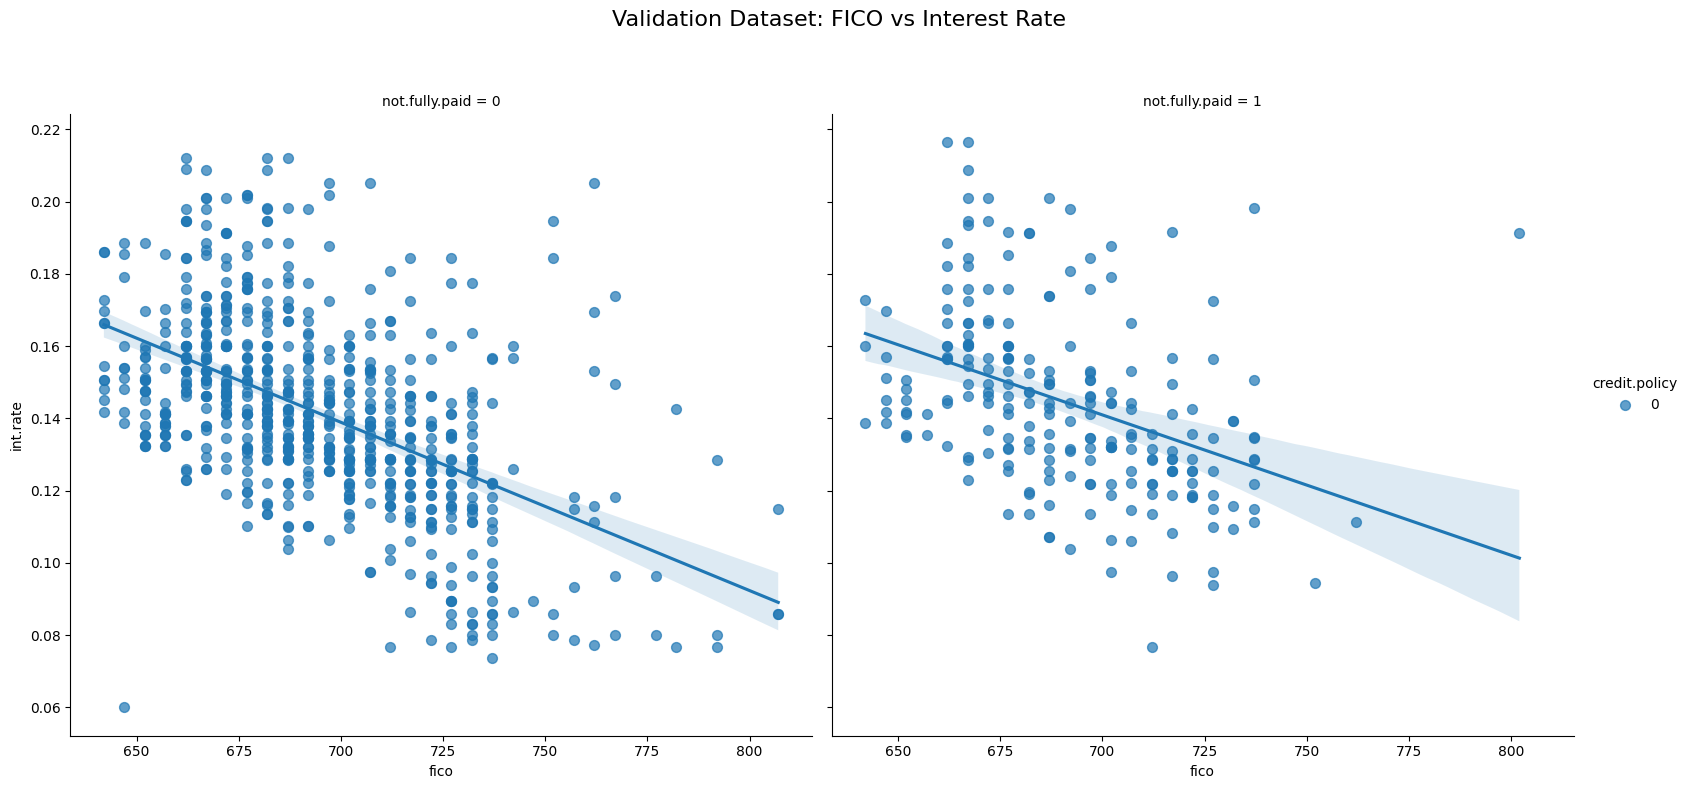

In [121]:
g = sns.lmplot(data=df_validation, x='fico', y='int.rate', hue='credit.policy', col='not.fully.paid', 
               logistic=False, aspect=1, height=8, scatter_kws={'s': 50, 'alpha': 0.7})

# Add title to the plot
g.fig.suptitle('Validation Dataset: FICO vs Interest Rate', fontsize=16)

# Adjust the layout to prevent title overlap
g.fig.subplots_adjust(top=0.85)

# Display the plot
plt.show()

2.6 - Please write a paragraph explaining the information and insights obtained from the charts you plotted.

The charts displayed provide insights into the relationship between FICO scores and interest rates, both for training and validation datasets.  </br>
In the first set of charts, we observe the distribution of FICO scores for two different credit policies (credit.policy = 1 and credit.policy = 0) for both training and validation data. </br>
The histograms, coupled with density plots, highlight that individuals with a credit.policy = 1 tend to have higher FICO scores than those with credit.policy = 0, with the latter showing a lower frequency of high FICO scores. This indicates that individuals with higher FICO scores are more likely to meet the credit policy criteria.


In the second set of plots, we look at the relationship between fico and int.rate based on whether the loan is fully paid or not (not.fully.paid). </br>
The plots reveal that individuals who have not fully paid their loans (denoted by not.fully.paid = 1) tend to have higher interest rates, as reflected by the downward slope of the regression line. </br>
Moreover, the credit.policy = 1 group, regardless of whether the loan is paid, has a slightly lower interest rate compared to the credit.policy = 0 group. </br

>
This suggests that individuals meeting the credit policy are considered lower-risk borrowers and are charged lower interest rates.

# 3 Data Setup

3.1 - Why is it necessary to convert categorical data into numeric data for machine learning models? How does this process affect the model's performance? Should all categorical data be converted to numeric data, and does this conversion always have a positive impact on the model's performance?

In machine learning, most algorithms require numerical data because they rely on mathematical operations like addition and subtraction, which cannot be applied to categorical data directly. </br>
Converting categorical data into numeric form allows the model to learn patterns.


Impact on Model Performance: The conversion method can affect model performance:


One-Hot Encoding is suitable for nominal categories (no order), turning each category into a binary column.</br>
Label Encoding is better for ordinal categories (with an order), assigning a unique integer to each category.</br>
Necessity of Conversion: Yes, categorical data must be converted to numeric data for machine learning models. </br>
However, the method depends on the type of data and the algorithm.


Does Conversion Always Improve Performance? Not necessarily. Incorrect encoding (e.g., label encoding for nominal variables) can mislead the model and reduce performance. The right encoding strategy is crucial for optimal performance.

# 4. Implementing model (Decision Tree & Random Forest)

4.1 - Train a Decision Tree model on the training dataset

In [122]:
# Splitting the data into features and target variables for training and validation
train_x = df_train.drop('not.fully.paid', axis=1)
train_y = df_train['not.fully.paid']

validation_x = df_validation.drop('not.fully.paid', axis=1)
validation_y = df_validation['not.fully.paid']

In [123]:
# Initializing the Decision Tree model
decision_tree = DecisionTreeClassifier()

# Training the model on the training dataset
decision_tree.fit(train_x, train_y) 

DecisionTreeClassifier()

In [124]:
# Initializing the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100) # n_estimators: Number of random trees
# sometimes random_state can be used for using the same initial random values

# Training the model on the training dataset
random_forest.fit(train_x, train_y)

RandomForestClassifier()

# 5. Prediction & Evaluation

5.1 - Please make a prediction for the test dataset

In [125]:
# Making predictions on the validation dataset
decision_tree_preds = decision_tree.predict(validation_x)

# Evaluating the model's performance on the validation dataset
accuracy = accuracy_score(validation_y, decision_tree_preds)

# Printing the accuracy
print(f'Accuracy on the validation dataset: {accuracy}')

Accuracy on the validation dataset: 0.5480167014613778


In [126]:
# Making predictions on the validation dataset
random_forest_preds = random_forest.predict(validation_x)

# Evaluating the model's performance on the validation dataset
accuracy = accuracy_score(validation_y, random_forest_preds)

# Printing the accuracy
print(f'Accuracy on the validation dataset: {accuracy}')

Accuracy on the validation dataset: 0.7118997912317327


5.2 - For the evaluation of classification models, the following metrics are commonly used: **Precision**, **Recall**, **F1-Score (Macro)**, **F1-Score (Micro)**, and **ROC-AUC**.  

- **a)** Define each metric and explain how it is calculated.  
- **b)** Discuss what each metric represents in terms of model performance and in which scenarios it is most useful.  
- **c)** Compare **F1-Score (Macro)** and **F1-Score (Micro)**, highlighting the differences in their calculations and applications.  
- **d)** Explain how the **ROC-AUC** metric helps in evaluating model performance across different classification thresholds.  

Make sure to provide examples or scenarios where each metric would be particularly valuable.

5.3 - Please compare your predicctions of your models and test labels and evaluate your models. You can see the evaluation metrics below:


- Classification Report
- Confusion Matrix
- F1-Score (macro)
- F1-Score (micro)
- ROC-AUC

In [127]:
# checking out the uniqueness in validation_y
print(np.unique(validation_y))

[0 1]


In [128]:
print(random_forest.predict_proba(validation_x)[:, 1])
print(decision_tree.predict_proba(validation_x)[:, 1])

[0.06 0.14 0.27 0.35 0.26 0.18 0.21 0.08 0.25 0.45 0.16 0.21 0.4  0.36
 0.2  0.32 0.19 0.55 0.25 0.12 0.25 0.25 0.48 0.34 0.21 0.4  0.39 0.39
 0.17 0.29 0.25 0.08 0.38 0.31 0.3  0.3  0.28 0.25 0.35 0.4  0.38 0.08
 0.36 0.28 0.45 0.18 0.31 0.27 0.35 0.41 0.34 0.18 0.21 0.16 0.35 0.15
 0.21 0.25 0.32 0.35 0.36 0.26 0.29 0.27 0.27 0.22 0.08 0.36 0.23 0.25
 0.42 0.13 0.45 0.17 0.2  0.24 0.34 0.24 0.23 0.22 0.32 0.35 0.48 0.51
 0.48 0.22 0.45 0.31 0.26 0.34 0.31 0.36 0.29 0.3  0.18 0.12 0.33 0.21
 0.39 0.26 0.11 0.25 0.36 0.31 0.21 0.5  0.23 0.4  0.28 0.36 0.17 0.23
 0.29 0.37 0.27 0.11 0.18 0.12 0.39 0.33 0.34 0.3  0.37 0.21 0.29 0.26
 0.23 0.26 0.27 0.21 0.2  0.17 0.41 0.45 0.5  0.32 0.31 0.27 0.32 0.11
 0.31 0.16 0.44 0.24 0.35 0.53 0.34 0.24 0.22 0.25 0.31 0.27 0.24 0.28
 0.22 0.29 0.24 0.29 0.33 0.37 0.29 0.36 0.24 0.34 0.36 0.19 0.21 0.15
 0.24 0.23 0.35 0.29 0.31 0.29 0.47 0.4  0.25 0.19 0.47 0.26 0.34 0.2
 0.26 0.51 0.37 0.24 0.37 0.21 0.31 0.17 0.46 0.15 0.34 0.22 0.2  0.33
 0.27 0

In [129]:
def display_metrics(model_name, y_true, y_pred, y_prob=None):
    print(f"\n\n===== Metrics for {model_name} =====")
    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_df = pd.DataFrame(conf_matrix, 
                                  index=["True Negative", "True Positive"], 
                                  columns=["Predicted Negative", "Predicted Positive"])
    print(conf_matrix_df)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    print(f"F1-Score (Macro): {f1_macro:.4f}")
    print(f"F1-Score (Micro): {f1_micro:.4f}")
    if ((y_prob is not None) and (len(np.unique(validation_y)) > 1)):
        roc_auc = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC: {roc_auc:.4f}")
    else:
        print("ROC-AUC: Not applicable (no probability predictions available)")

display_metrics("Random Forest", validation_y, random_forest_preds, 
                random_forest.predict_proba(validation_x)[:, 1])

display_metrics("Decision Tree", validation_y, decision_tree_preds, 
                decision_tree.predict_proba(validation_x)[:, 1])



===== Metrics for Random Forest =====

Confusion Matrix:
               Predicted Negative  Predicted Positive
True Negative                 635                  96
True Positive                 180                  47

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       731
           1       0.33      0.21      0.25       227

    accuracy                           0.71       958
   macro avg       0.55      0.54      0.54       958
weighted avg       0.67      0.71      0.69       958

F1-Score (Macro): 0.5378
F1-Score (Micro): 0.7119
ROC-AUC: 0.5619


===== Metrics for Decision Tree =====

Confusion Matrix:
               Predicted Negative  Predicted Positive
True Negative                 435                 296
True Positive                 137                  90

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.60      0.67       731
        